DCGAN — Geração de rostos com CelebA
======================================

Adaptação do DCGAN original (MNIST) para o dataset **CelebA** (rostos de celebridades).

Artigo original: [Goodfellow et al (2020)](https://dl.acm.org/doi/abs/10.1145/3422622)

Arquitetura DCGAN: [Radford et al, 2015](https://arxiv.org/abs/1511.06434)

**Como rodar no Kaggle:**
1. Crie um novo Notebook no Kaggle.
2. No menu lateral *Data*, adicione o dataset **`jessicali9530/celeba-dataset`**.
3. Ative o acelerador **GPU** (Settings → Accelerator → GPU T4 x2 ou P100).
4. Rode as células em ordem.

Duas redes competem:
- O **Gerador** recebe um vetor de ruído e cria rostos falsos.
- O **Discriminador** tenta diferenciar rostos reais (CelebA) dos falsos.

In [12]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.utils import save_image, make_grid
from PIL import Image
import matplotlib.pyplot as plt

Hiperparâmetros
===============

Diferenças em relação ao MNIST:
- `img_shape = (3, 64, 64)`: agora são imagens **coloridas (RGB)** de **64×64** pixels.
- `batch_size = 128`: GPU comporta lotes maiores.
- `epochs = 15`: CelebA tem ~200k imagens, então cada época já é bastante treino.
- `latent_dim = 100`: mantido (continua sendo um bom valor).

In [13]:
latent_dim = 100
img_channels = 3
img_size = 64
batch_size = 128
epochs = 10
learning_rate = 0.0002

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

Dispositivo: cuda


Dataset CelebA no Kaggle
=========================

Quando você adiciona o dataset `jessicali9530/celeba-dataset` ao notebook do Kaggle, as imagens ficam em:

```
/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba/*.jpg
```

São ~202.599 imagens de rostos já alinhados. Como é uma pasta plana de `.jpg` (sem subpastas por classe), não dá pra usar `ImageFolder` diretamente — escrevemos um `Dataset` customizado.

As imagens originais são 178×218. Vamos redimensionar para 64×64 (`Resize` + `CenterCrop`) — tamanho clássico do DCGAN e mais leve pra treinar.

In [14]:
  DATA_ROOT = '/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba'

transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    # Normaliza nos 3 canais (RGB) para o intervalo [-1, 1] (combina com Tanh do gerador)
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

class CelebADataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.files = sorted([f for f in os.listdir(root) if f.endswith('.jpg')])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root, self.files[idx])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

dataset = CelebADataset(DATA_ROOT, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
print(f'Total de imagens: {len(dataset)}')
print(f'Batches por época: {len(dataloader)}')

Total de imagens: 202599
Batches por época: 1583


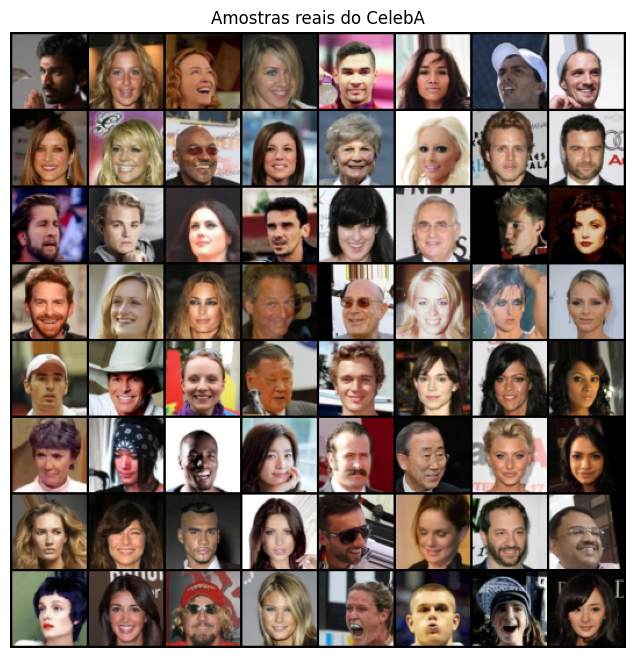

In [15]:
# Visualizar algumas imagens reais para confirmar que o pipeline está OK
real_batch = next(iter(dataloader))
plt.figure(figsize=(8, 8))
plt.axis('off')
plt.title('Amostras reais do CelebA')
grid = make_grid(real_batch[:64], padding=2, normalize=True)
plt.imshow(grid.permute(1, 2, 0))
plt.show()

Gerador (Generator)
===================

Recebe um vetor latente de 100 dimensões e o transforma progressivamente, via `ConvTranspose2d` (convolução transposta = upsampling aprendido), em uma imagem **3×64×64**.

Caminho dos tamanhos: `1×1 → 4×4 → 8×8 → 16×16 → 32×32 → 64×64`.

Cada bloco: `ConvTranspose2d → BatchNorm2d → ReLU`. A última camada usa `Tanh` para sair em `[-1, 1]` (mesmo intervalo das imagens reais normalizadas).

In [16]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # entrada: (batch, latent_dim, 1, 1)
            nn.ConvTranspose2d(latent_dim, 512, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # (batch, 512, 4, 4)
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # (batch, 256, 8, 8)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # (batch, 128, 16, 16)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # (batch, 64, 32, 32)
            nn.ConvTranspose2d(64, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
            # saída: (batch, 3, 64, 64)
        )

    def forward(self, z):
        # z chega como (batch, latent_dim); reformatamos para (batch, latent_dim, 1, 1)
        z = z.view(z.size(0), latent_dim, 1, 1)
        return self.model(z)

Discriminador (Discriminator)
=============================

Recebe uma imagem **3×64×64** e a reduz progressivamente, via `Conv2d`, até produzir um único número entre 0 e 1 (probabilidade de ser real).

Caminho dos tamanhos: `64×64 → 32×32 → 16×16 → 8×8 → 4×4 → 1×1`.

Cada bloco: `Conv2d → (BatchNorm2d) → LeakyReLU(0.2)`. A primeira camada **não** usa BatchNorm (recomendação do paper).

In [17]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # entrada: (batch, 3, 64, 64)
            nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (batch, 64, 32, 32)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # (batch, 128, 16, 16)
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # (batch, 256, 8, 8)
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # (batch, 512, 4, 4)
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()
            # saída: (batch, 1, 1, 1) -> achatamos para (batch, 1)
        )

    def forward(self, img):
        return self.model(img).view(-1, 1)

Inicialização de pesos
======================

O paper do DCGAN recomenda inicializar todos os pesos com distribuição normal `N(0, 0.02)`. Isso ajuda muito na estabilidade do treino de GANs.

In [18]:
  import torch
  print('PyTorch:', torch.__version__)
  print('CUDA disponível:', torch.cuda.is_available())
  print('CUDA version do PyTorch:', torch.version.cuda)
  if torch.cuda.is_available():
      print('GPU:', torch.cuda.get_device_name(0))
      print('Capability:', torch.cuda.get_device_capability(0))


PyTorch: 2.10.0+cu128
CUDA disponível: True
CUDA version do PyTorch: 12.8
GPU: Tesla T4
Capability: (7, 5)


In [19]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

generator = Generator().to(device)
discriminator = Discriminator().to(device)
generator.apply(weights_init)
discriminator.apply(weights_init)
print(generator)
print(discriminator)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

Função de perda e otimizadores
==============================

- `BCELoss`: perda binária (real vs falso).
- `Adam` com `betas=(0.5, 0.999)`: configuração clássica para estabilizar GANs.

In [20]:
criterion = nn.BCELoss().to(device)
optimizer_G = optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))

# Vetor latente fixo para acompanhar a evolução do gerador ao longo das épocas
fixed_noise = torch.randn(64, latent_dim, device=device)

Treinamento Adversarial
========================

A cada batch:
1. **Discriminador**: vê um lote de imagens reais (rótulo 1) e um lote de imagens falsas geradas (rótulo 0). Aprende a separá-las.
2. **Gerador**: cria novas imagens falsas e tenta fazer o discriminador classificá-las como reais (rótulo 1). Aprende a enganá-lo.

A cada época, salvamos uma grade de 64 rostos gerados a partir do mesmo vetor de ruído `fixed_noise`, pra ver visualmente a evolução.

In [21]:
OUTPUT_DIR = '/kaggle/working/images_celeba'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def train_dcgan(epochs):
    G_losses, D_losses = [], []
    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            bs = imgs.size(0)
            real_imgs = imgs.to(device)
            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # --- Treina o Discriminador ---
            optimizer_D.zero_grad()
            real_loss = criterion(discriminator(real_imgs), real_labels)
            z = torch.randn(bs, latent_dim, device=device)
            fake_imgs = generator(z)
            fake_loss = criterion(discriminator(fake_imgs.detach()), fake_labels)
            d_loss = real_loss + fake_loss
            d_loss.backward()
            optimizer_D.step()

            # --- Treina o Gerador ---
            optimizer_G.zero_grad()
            g_loss = criterion(discriminator(fake_imgs), real_labels)
            g_loss.backward()
            optimizer_G.step()

            if i % 200 == 0:
                print(f'Epoch [{epoch+1}/{epochs}] Batch {i}/{len(dataloader)} '
                      f'Loss D: {d_loss.item():.4f}  Loss G: {g_loss.item():.4f}')

            G_losses.append(g_loss.item())
            D_losses.append(d_loss.item())

        # Salva amostras com o ruído fixo para comparação ao longo das épocas
        with torch.no_grad():
            samples = generator(fixed_noise).detach().cpu()
        save_image(samples, f'{OUTPUT_DIR}/epoch_{epoch+1:02d}.png', nrow=8, normalize=True)

    return G_losses, D_losses

G_losses, D_losses = train_dcgan(epochs)

Epoch [1/10] Batch 0/1583 Loss D: 1.6091  Loss G: 3.9220
Epoch [1/10] Batch 200/1583 Loss D: 0.4559  Loss G: 4.8882
Epoch [1/10] Batch 400/1583 Loss D: 0.4752  Loss G: 5.5873
Epoch [1/10] Batch 600/1583 Loss D: 0.6531  Loss G: 7.4609
Epoch [1/10] Batch 800/1583 Loss D: 0.2944  Loss G: 4.2847
Epoch [1/10] Batch 1000/1583 Loss D: 0.3052  Loss G: 4.0252
Epoch [1/10] Batch 1200/1583 Loss D: 0.4659  Loss G: 4.8365
Epoch [1/10] Batch 1400/1583 Loss D: 0.2423  Loss G: 4.2646
Epoch [2/10] Batch 0/1583 Loss D: 1.2558  Loss G: 8.2802
Epoch [2/10] Batch 200/1583 Loss D: 0.3925  Loss G: 4.0617
Epoch [2/10] Batch 400/1583 Loss D: 0.5865  Loss G: 3.5332
Epoch [2/10] Batch 600/1583 Loss D: 0.6042  Loss G: 2.0629
Epoch [2/10] Batch 800/1583 Loss D: 0.9185  Loss G: 4.8472
Epoch [2/10] Batch 1000/1583 Loss D: 0.6939  Loss G: 2.1445
Epoch [2/10] Batch 1200/1583 Loss D: 0.5794  Loss G: 4.4752
Epoch [2/10] Batch 1400/1583 Loss D: 1.0500  Loss G: 0.9641
Epoch [3/10] Batch 0/1583 Loss D: 1.2578  Loss G: 5.07

Resultados
==========

Comparação visual entre rostos reais e rostos gerados, além da curva de perda.

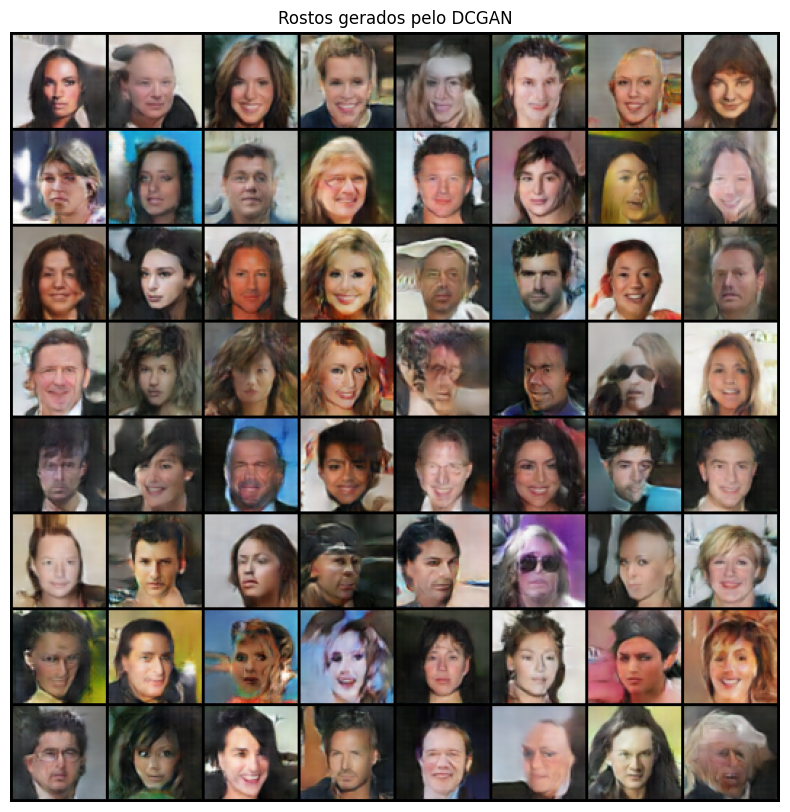

In [22]:
# Gera 64 rostos novos com o gerador treinado
generator.eval()
with torch.no_grad():
    z = torch.randn(64, latent_dim, device=device)
    fake_imgs = generator(z).detach().cpu()

plt.figure(figsize=(10, 10))
plt.axis('off')
plt.title('Rostos gerados pelo DCGAN')
plt.imshow(make_grid(fake_imgs, padding=2, normalize=True).permute(1, 2, 0))
plt.savefig('/kaggle/working/final_samples.png', bbox_inches='tight')
plt.show()

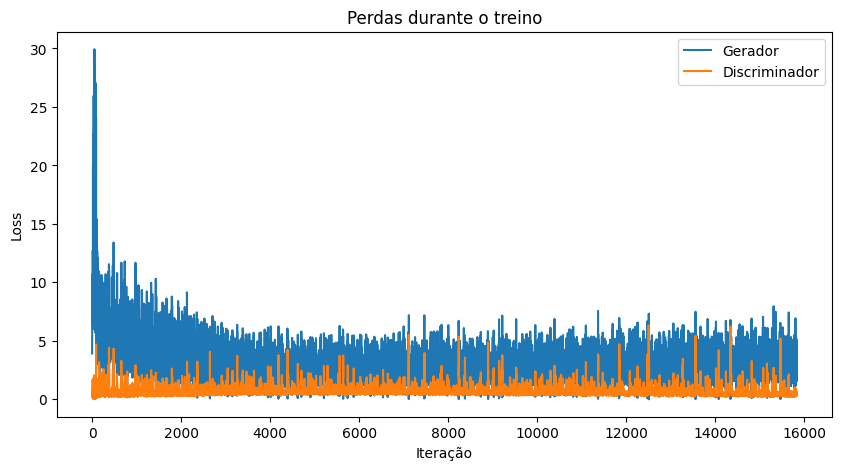

In [23]:
plt.figure(figsize=(10, 5))
plt.title('Perdas durante o treino')
plt.plot(G_losses, label='Gerador')
plt.plot(D_losses, label='Discriminador')
plt.xlabel('Iteração')
plt.ylabel('Loss')
plt.legend()
plt.savefig('/kaggle/working/loss_curves.png', bbox_inches='tight')
plt.show()

In [24]:
# Salva os pesos treinados para reuso
torch.save(generator.state_dict(), '/kaggle/working/generator.pth')
torch.save(discriminator.state_dict(), '/kaggle/working/discriminator.pth')
print('Modelos salvos em /kaggle/working/')

Modelos salvos em /kaggle/working/


Interpretação das perdas
========================

**Loss D** mede o quão bem o discriminador separa rostos reais de falsos. Idealmente oscila em torno de valores intermediários — se cair para perto de 0, ele está dominando e o gerador para de aprender.

**Loss G** mede o quão bem o gerador engana o discriminador. Deve diminuir ao longo do treino, mas não deve ir para 0 (sinal de *mode collapse* — o gerador encontrou uma imagem que sempre engana e parou de variar).

**Mode collapse**: o gerador descobre uns poucos rostos que enganam o discriminador e passa a produzir só eles, perdendo diversidade.

**Instabilidade**: GANs são notoriamente difíceis de treinar. Se algo der errado (perda explodindo, imagens viraram ruído), tente:
- diminuir o `learning_rate` (ex.: `1e-4`)
- treinar o discriminador menos vezes que o gerador
- usar `label smoothing` (rótulos reais = 0.9 em vez de 1.0)